Grid shape: (40, 40)   (1600 parameters)
True surface  min=-9.98 km  max=9.98 km  std=5.01 km

Forward modeling (true model) ...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Observed gravity  min=-142.43  max=159.09  std=70.48 mGal

Starting inversion ...
Gauss-Newton inversion  (Bott Jacobian + Armijo line search)
  n_params=1600   μ=0.0   max_iter=20
  iter  0:  rms=70.4922 mGal   φ=7.9506e+06
  iter  1:  rms=30.3222 mGal   φ=1.4711e+06   Δφ/φ=+8.15e-01   α=1.0000
  iter  2:  rms=13.5371 mGal   φ=2.9320e+05   Δφ/φ=+8.01e-01   α=1.0000
  iter  3:  rms=6.4782 mGal   φ=6.7147e+04   Δφ/φ=+7.71e-01   α=1.0000
  iter  4:  rms=3.4150 mGal   φ=1.8660e+04   Δφ/φ=+7.22e-01   α=1.0000
  iter  5:  rms=2.0061 mGal   φ=6.4394e+03   Δφ/φ=+6.55e-01   α=1.0000
  iter  6:  rms=1.3023 mGal   φ=2.7135e+03   Δφ/φ=+5.79e-01   α=1.0000
  iter  7:  rms=0.9159 mGal   φ=1.3423e+03   Δφ/φ=+5.05e-01   α=1.0000
  iter  8:  rms=0.6842 mGal   φ=7.4891e+02   Δφ/φ=+4.42e-01   α=1.0000
  iter  9:  rms=0.5342 mGal   φ=4.5660e+02   Δφ/φ=+3.90e-01   α=1.0000
  iter 10:  rms=0.4311 mGal   φ=2.9737e+02   Δφ/φ=+3.49e-01   α=1.0000
  iter 11:  rms=0.3567 mGal   φ=2.0362e+02   Δφ/φ=+3.15e-01   α

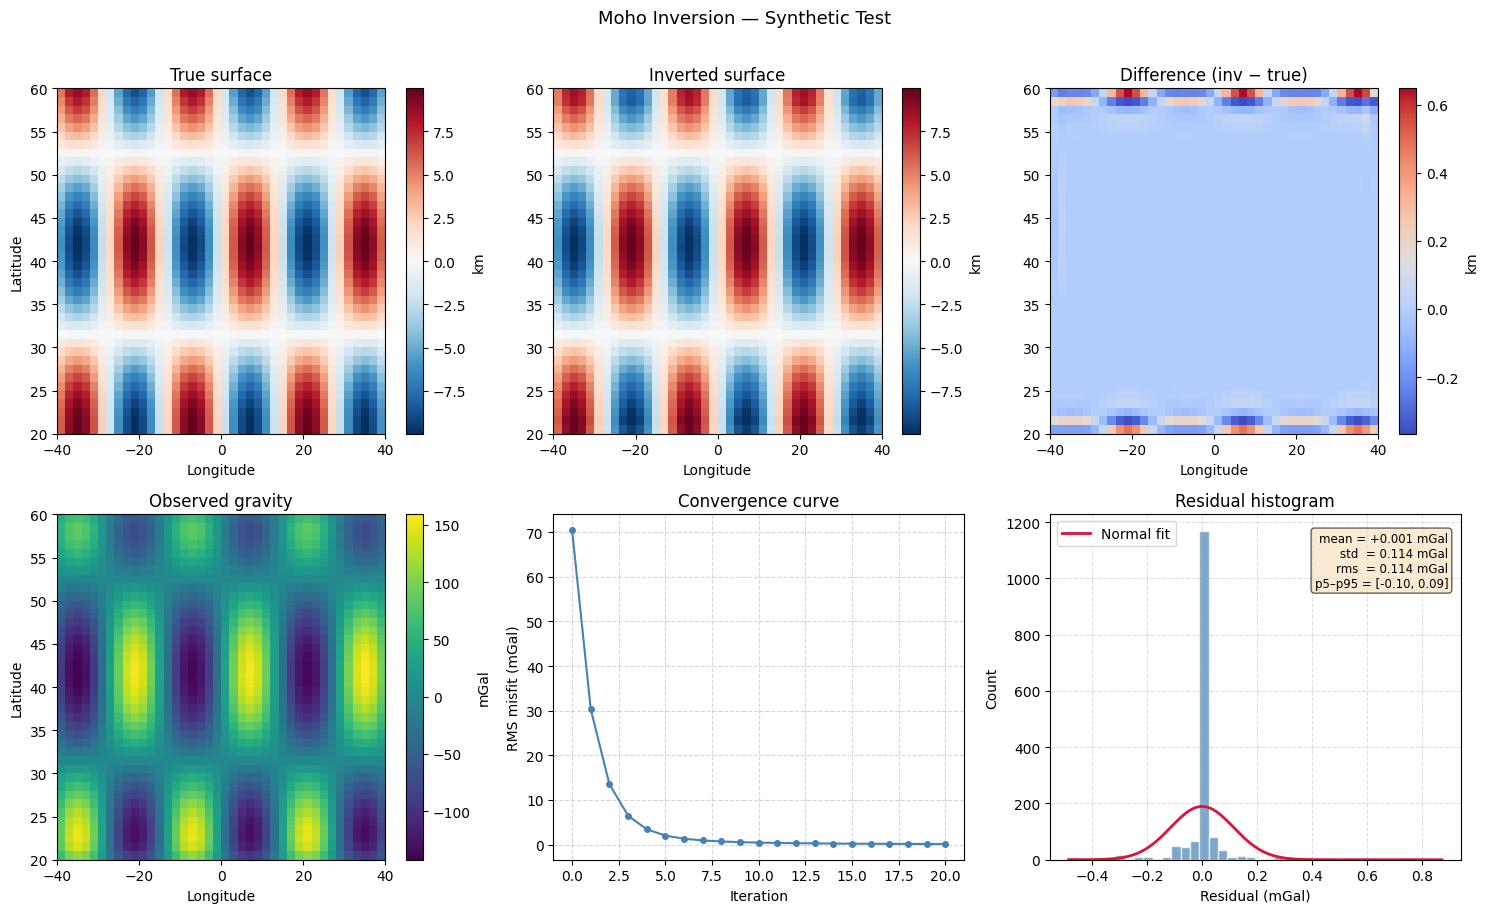


Figure saved: moho_inversion_test.png


'\niters, rms = inv.convergence_data()\nnp.savetxt(\n    "convergence.txt",\n    np.column_stack([iters, rms]),\n    header="iteration  rms_mGal",\n    fmt=["%d", "%.6f"],\n)\n\ncounts, bin_edges, bin_centers = inv.residual_histogram_data(bins=40)\nnp.savetxt(\n    "residual_histogram.txt",\n    np.column_stack([bin_centers, counts]),\n    header="bin_center_mGal  count",\n    fmt=["%.6f", "%d"],\n)\n\nprint("Data saved: convergence.txt, residual_histogram.txt")\n'

In [2]:
"""
合成数据测试：MohoLayer + MohoInversion
========================================
流程：
1. 构造真实莫霍面（bipolar_surface_2）
2. 正演计算观测重力
3. 以零起伏为初始猜测，反演恢复莫霍面
4. 输出收敛曲线、残差直方图、结果对比图
"""

import numpy as np
import matplotlib.pyplot as plt
import verde as vd

# 把 moho_inversion.py 放在同一目录下
from mohoinv_development_7 import MohoLayer, MohoInversion


# ==============================================================================
# 1. 网格设置
# ==============================================================================

region = (-40, 40, 20, 60)   # (lon_min, lon_max, lat_min, lat_max)

# verde 给出网格节点坐标（41×41）
grid_lon, grid_lat = vd.grid_coordinates(region=region, shape=(41, 41))

lon_o = np.sort(np.unique(grid_lon))
lat_o = np.sort(np.unique(grid_lat))

# 取相邻节点中心作为单元格中心（40×40）
lon = 0.5 * (lon_o[:-1] + lon_o[1:])
lat = 0.5 * (lat_o[:-1] + lat_o[1:])

LON, LAT = np.meshgrid(lon, lat)
shape = LON.shape
print(f"Grid shape: {shape}   ({shape[0]*shape[1]} parameters)")


# ==============================================================================
# 2. 真实莫霍面
# ==============================================================================

def bipolar_surface_2(lat, lon, f=0.15):
    return 10e3 * np.sin(1.5 * f * lon) * np.cos(f * lat)

reference        = -35e3 * np.ones(shape)   # 参考深度 -35 km
height_obs       = 11e3                      # 观测高度 11 km
density_contrast = 600.0                     # kg/m³

surface_true = bipolar_surface_2(LAT, LON)

print(f"True surface  min={surface_true.min()/1e3:.2f} km  "
      f"max={surface_true.max()/1e3:.2f} km  "
      f"std={surface_true.std()/1e3:.2f} km")


# ==============================================================================
# 3. 正演：生成"观测"重力
# ==============================================================================

layer_true = MohoLayer(
    lon=lon,
    lat=lat,
    height=height_obs,
    reference=reference,
    surface=surface_true,
    density_contrast=density_contrast * np.ones(shape),
)

print("\nForward modeling (true model) ...")
go = layer_true.forward(quite=True)
print(f"Observed gravity  min={go.min():.2f}  max={go.max():.2f}  "
      f"std={go.std():.2f} mGal")


# ==============================================================================
# 4. 反演：初始猜测 = 零起伏
# ==============================================================================

surface_init = np.zeros(shape)   # 初始猜测：莫霍面无起伏

layer_init = MohoLayer(
    lon=lon,
    lat=lat,
    height=height_obs,
    reference=reference,
    surface=surface_init,
    density_contrast=density_contrast * np.ones(shape),
)

inv = MohoInversion(
    layer=layer_init,
    go=go,
    max_iter=20,
    mu=0.0,      # 先不加正则化，看收敛情况
    quite=True,
)

print("\nStarting inversion ...")
surface_inv = inv.inversion_gn(gtol=1e-4)


# ==============================================================================
# 5. 统计
# ==============================================================================

diff = surface_inv - surface_true
print(f"\nRecovery error (inv - true):")
print(f"  mean = {diff.mean()/1e3:.3f} km")
print(f"  std  = {diff.std()/1e3:.3f} km")
print(f"  max  = {np.abs(diff).max()/1e3:.3f} km")

stats = inv.residual_stats()
print(f"\nFinal residual stats:")
for k, v in stats.items():
    print(f"  {k:5s} = {v:.4f} mGal")


# ==============================================================================
# 6. 绘图
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# ---- (a) 真实莫霍面 ----
ax = axes[0, 0]
im = ax.pcolormesh(LON, LAT, surface_true / 1e3, cmap="RdBu_r", shading="auto")
plt.colorbar(im, ax=ax, label="km")
ax.set_title("True surface")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ---- (b) 反演结果 ----
ax = axes[0, 1]
vmax = np.abs(surface_true).max() / 1e3
im = ax.pcolormesh(LON, LAT, surface_inv / 1e3, cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, shading="auto")
plt.colorbar(im, ax=ax, label="km")
ax.set_title("Inverted surface")
ax.set_xlabel("Longitude")

# ---- (c) 差值（恢复误差）----
ax = axes[0, 2]
im = ax.pcolormesh(LON, LAT, diff / 1e3, cmap="coolwarm", shading="auto")
plt.colorbar(im, ax=ax, label="km")
ax.set_title("Difference (inv − true)")
ax.set_xlabel("Longitude")

# ---- (d) 观测重力 ----
ax = axes[1, 0]
im = ax.pcolormesh(LON, LAT, go, cmap="viridis", shading="auto")
plt.colorbar(im, ax=ax, label="mGal")
ax.set_title("Observed gravity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ---- (e) 收敛曲线 ----
ax = axes[1, 1]
inv.plot_convergence(ax=ax)

# ---- (f) 残差直方图 ----
ax = axes[1, 2]
inv.plot_residual_histogram(bins=40, ax=ax)

plt.suptitle("Moho Inversion — Synthetic Test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("moho_inversion_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved: moho_inversion_test.png")


# ==============================================================================
# 7. 保存收敛曲线和直方图数据（方便后续分析）
# ==============================================================================
'''
iters, rms = inv.convergence_data()
np.savetxt(
    "convergence.txt",
    np.column_stack([iters, rms]),
    header="iteration  rms_mGal",
    fmt=["%d", "%.6f"],
)

counts, bin_edges, bin_centers = inv.residual_histogram_data(bins=40)
np.savetxt(
    "residual_histogram.txt",
    np.column_stack([bin_centers, counts]),
    header="bin_center_mGal  count",
    fmt=["%.6f", "%d"],
)

print("Data saved: convergence.txt, residual_histogram.txt")
'''

True surface  min=-5.51 km  max=7.15 km  std=1.06 km

Forward modeling ...
Observed gravity  min=-74.98  max=102.17  std=17.11 mGal

Starting inversion ...
Gauss-Newton inversion  (Bott Jacobian + Armijo line search)
  n_params=1600   μ=0.0   max_iter=20
  iter  0:  rms=17.1076 mGal   φ=4.6827e+05
  iter  1:  rms=5.6968 mGal   φ=5.1925e+04   Δφ/φ=+8.89e-01   α=1.0000
  iter  2:  rms=2.5203 mGal   φ=1.0163e+04   Δφ/φ=+8.04e-01   α=1.0000
  iter  3:  rms=1.3023 mGal   φ=2.7135e+03   Δφ/φ=+7.33e-01   α=1.0000
  iter  4:  rms=0.7448 mGal   φ=8.8750e+02   Δφ/φ=+6.73e-01   α=1.0000
  iter  5:  rms=0.4576 mGal   φ=3.3510e+02   Δφ/φ=+6.22e-01   α=1.0000
  iter  6:  rms=0.2971 mGal   φ=1.4127e+02   Δφ/φ=+5.78e-01   α=1.0000
  iter  7:  rms=0.2019 mGal   φ=6.5199e+01   Δφ/φ=+5.38e-01   α=1.0000
  iter  8:  rms=0.1426 mGal   φ=3.2513e+01   Δφ/φ=+5.01e-01   α=1.0000
  iter  9:  rms=0.1041 mGal   φ=1.7355e+01   Δφ/φ=+4.66e-01   α=1.0000
  iter 10:  rms=0.0784 mGal   φ=9.8408e+00   Δφ/φ=+4.33e-01   

/Users/aoluowei/CODE/Pythoncode/neustr_Moho_inversion/mohoinv_development_7.py:431: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) Arial.
  fig.tight_layout()
/Users/aoluowei/CODE/Pythoncode/neustr_Moho_inversion/mohoinv_development_7.py:431: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.tight_layout()
/Users/aoluowei/CODE/Pythoncode/neustr_Moho_inversion/mohoinv_development_7.py:431: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from font(s) Arial.
  fig.tight_layout()
Exception ignored in: <function tqdm.__del__ at 0x10e8c45e0>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/geoenv/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/miniconda3/envs/geoenv/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has 

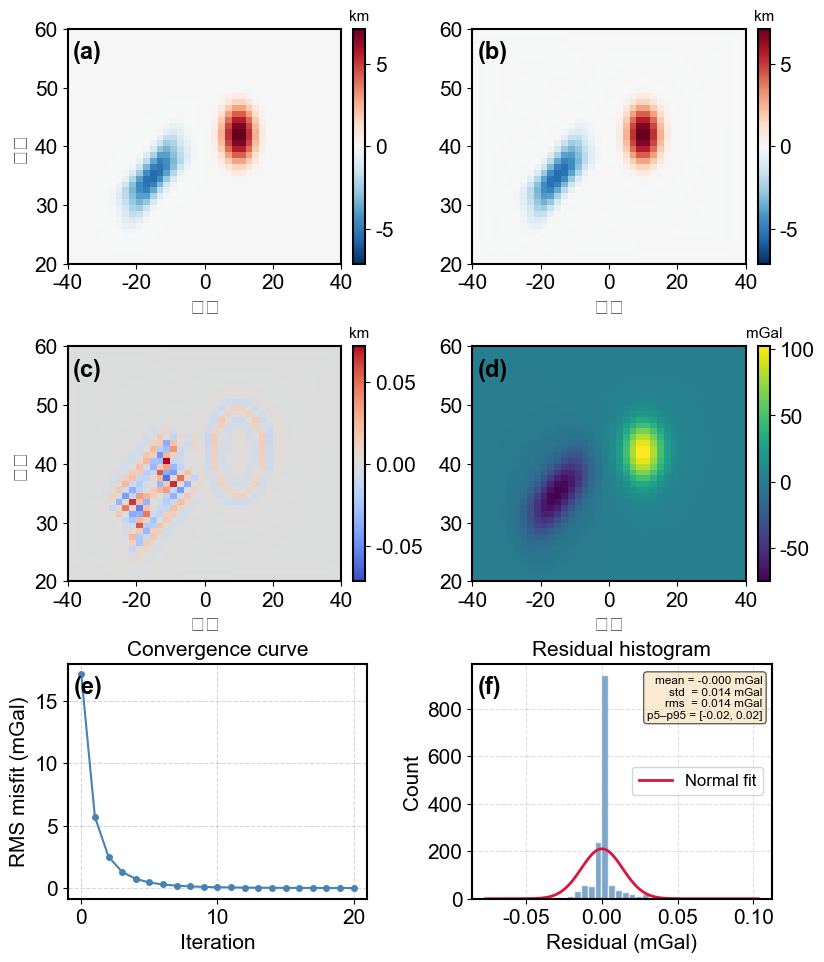

In [4]:
import numpy as np


def synthetic_surface(LON, LAT,
                      # 圆形凸起参数
                      bump_center=(0, 42),    # (lon, lat)
                      bump_radius=8,           # 度
                      bump_height=8e3,         # m，正值=向上
                      # 矩形下凹参数
                      rect_center=(-15, 35),  # (lon, lat)
                      rect_half=(12, 5),       # 半长轴、半短轴（度）
                      rect_angle=35,           # 旋转角度（度，逆时针）
                      rect_depth=6e3,          # m，正值=向下凹（取负）
                      # 平滑参数
                      smooth_sigma=1.5):       # 高斯平滑，度
    """
    合成莫霍面起伏：圆形凸起 + 倾斜矩形下凹

    参数
    ----
    LON, LAT      : meshgrid 坐标（度）
    bump_center   : 圆形凸起中心 (lon, lat)
    bump_radius   : 圆形凸起半径（度）
    bump_height   : 凸起幅度（m，正值向上）
    rect_center   : 矩形下凹中心 (lon, lat)
    rect_half     : 矩形半长轴和半短轴（度），(a, b)
    rect_angle    : 矩形旋转角（度，逆时针为正）
    rect_depth    : 下凹深度（m，正值表示向下，内部取负）
    smooth_sigma  : 边缘高斯平滑宽度（度），避免不连续

    返回
    ----
    surface : 2D array，莫霍面起伏（m）
    """
    from scipy.ndimage import gaussian_filter

    surface = np.zeros_like(LON, dtype=float)

    # ------------------------------------------------------------------
    # 1. 圆形凸起（光滑余弦窗）
    # ------------------------------------------------------------------
    dist_bump = np.sqrt((LON - bump_center[0]) ** 2 +
                        (LAT - bump_center[1]) ** 2)
    inside_bump = dist_bump <= bump_radius
    surface[inside_bump] += bump_height * (
        0.5 * (1 + np.cos(np.pi * dist_bump[inside_bump] / bump_radius))
    )

    # ------------------------------------------------------------------
    # 2. 倾斜矩形下凹（超椭圆形状，幂次=8 近似矩形，再旋转）
    # ------------------------------------------------------------------
    angle_rad = np.deg2rad(rect_angle)
    # 把坐标旋转到矩形的局部坐标系
    dlon = LON - rect_center[0]
    dlat = LAT - rect_center[1]
    u =  dlon * np.cos(angle_rad) + dlat * np.sin(angle_rad)
    v = -dlon * np.sin(angle_rad) + dlat * np.cos(angle_rad)

    a, b = rect_half
    # 超椭圆：(u/a)^8 + (v/b)^8 <= 1 近似矩形
    superellipse = (np.abs(u) / a) ** 8 + (np.abs(v) / b) ** 8
    inside_rect = superellipse <= 1.0

    # 内部用余弦窗平滑边缘，避免硬边界
    # 把 superellipse 值映射到 [0,1] 做权重
    weight = np.zeros_like(LON)
    weight[inside_rect] = 0.5 * (
        1 + np.cos(np.pi * superellipse[inside_rect] ** (1/8))
    )
    surface -= rect_depth * weight

    # ------------------------------------------------------------------
    # 3. 整体高斯平滑（消除超椭圆边缘的数值噪声）
    # ------------------------------------------------------------------
    # 把空间平滑宽度转成像素数
    dlon_res = float(np.diff(LON[0, :]).mean())
    dlat_res = float(np.diff(LAT[:, 0]).mean())
    sigma_px = smooth_sigma / max(dlon_res, dlat_res)
    surface = gaussian_filter(surface, sigma=sigma_px)

    return surface

"""
合成数据测试：圆形凸起 + 倾斜矩形下凹
"""

import numpy as np
import matplotlib.pyplot as plt
import verde as vd

from mohoinv_development_7 import MohoLayer, MohoInversion


# ==============================================================================
# 1. 网格
# ==============================================================================

region = (-40, 40, 20, 60)
grid_lon, grid_lat = vd.grid_coordinates(region=region, shape=(41, 41))

lon_o = np.sort(np.unique(grid_lon))
lat_o = np.sort(np.unique(grid_lat))
lon = 0.5 * (lon_o[:-1] + lon_o[1:])
lat = 0.5 * (lat_o[:-1] + lat_o[1:])

LON, LAT = np.meshgrid(lon, lat)
shape = LON.shape


# ==============================================================================
# 2. 真实莫霍面
# ==============================================================================

surface_true = synthetic_surface(
    LON, LAT,
    bump_center=(10, 42),   # 圆形凸起：偏右侧
    bump_radius=8,
    bump_height=8e3,         # +8 km
    rect_center=(-15, 35),  # 矩形下凹：偏左下，斜着
    rect_half=(14, 5),
    rect_angle=35,
    rect_depth=6e3,          # -6 km
    smooth_sigma=1.2,
)

print(f"True surface  min={surface_true.min()/1e3:.2f} km  "
      f"max={surface_true.max()/1e3:.2f} km  "
      f"std={surface_true.std()/1e3:.2f} km")


# ==============================================================================
# 3. 正演生成观测重力
# ==============================================================================

reference        = -35e3 * np.ones(shape)
height_obs       = 11e3
density_contrast = 600.0 * np.ones(shape)

layer_true = MohoLayer(
    lon=lon, lat=lat,
    height=height_obs,
    reference=reference,
    surface=surface_true,
    density_contrast=density_contrast,
)

print("\nForward modeling ...")
go = layer_true.forward(quite=True)
print(f"Observed gravity  min={go.min():.2f}  max={go.max():.2f}  "
      f"std={go.std():.2f} mGal")


# ==============================================================================
# 4. 反演
# ==============================================================================

layer_init = MohoLayer(
    lon=lon, lat=lat,
    height=height_obs,
    reference=reference,
    surface=np.zeros(shape),
    density_contrast=density_contrast,
)

inv = MohoInversion(layer=layer_init, go=go, max_iter=20, mu=0.0, quite=True)

print("\nStarting inversion ...")
surface_inv = inv.inversion_gn(gtol=1e-4)


# ==============================================================================
# 5. 绘图
# ==============================================================================

# =========================
# 全局风格（投稿级）
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Noto Sans CJK JP", "SimHei", "Arial"],
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.unicode_minus": False,  # 关键：负号正常显示
})

# =========================
# 数据
# =========================
diff = surface_inv - surface_true
vmax_surf = np.nanmax(np.abs(surface_true)) / 1e3
vmax_diff = np.nanmax(np.abs(diff)) / 1e3

fig, axes = plt.subplots(3, 2, figsize=(8, 10))

# ===== (a) =====
ax = axes[0, 0]
im = ax.pcolormesh(LON, LAT, surface_true/1e3,
                   cmap="RdBu_r", vmin=-vmax_surf, vmax=vmax_surf, shading="auto")
cbar=plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_title("km", fontsize=11, pad=6)
ax.set_xlabel("经度")
ax.set_ylabel("纬度")
ax.text(0.02, 0.95, "(a)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# ===== (b) =====
ax = axes[0, 1]
im = ax.pcolormesh(LON, LAT, surface_inv/1e3,
                   cmap="RdBu_r", vmin=-vmax_surf, vmax=vmax_surf, shading="auto")
cbar=plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_title("km", fontsize=11, pad=6)
ax.set_xlabel("经度")
ax.text(0.02, 0.95, "(b)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# ===== (c) =====
ax = axes[1, 0]
im = ax.pcolormesh(LON, LAT, diff/1e3,
                   cmap="coolwarm", vmin=-vmax_diff, vmax=vmax_diff, shading="auto")
cbar=plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_title("km", fontsize=11, pad=6)
ax.set_ylabel("纬度")
ax.set_xlabel("经度")
ax.text(0.02, 0.95, "(c)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# ===== (d) =====
ax = axes[1, 1]
im = ax.pcolormesh(LON, LAT, go,
                   cmap="viridis", shading="auto")
cbar=plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_title("mGal", fontsize=11, pad=6)
ax.set_xlabel("经度")
ax.text(0.02, 0.95, "(d)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# ===== (e) 收敛 =====
ax = axes[2, 0]
inv.plot_convergence(ax=ax)
ax.text(0.02, 0.95, "(e)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# ===== (f) 残差 =====
ax = axes[2, 1]
inv.plot_residual_histogram(bins=40, ax=ax)
ax.text(0.02, 0.95, "(f)", transform=ax.transAxes,
        fontsize=17, fontweight="bold", va="top")

# =========================
# 总体排版
# =========================
plt.subplots_adjust(
    left=0.07,
    right=0.95,
    bottom=0.08,
    top=0.95,
    wspace=0.35,
    hspace=0.35
)

plt.savefig("moho_nature_clean.png", dpi=300)
plt.show()